In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

print("✅ Api configured")

✅ Api configured


In [2]:
from typing import TypedDict, Optional


class AgentState(TypedDict):
    """Shared state that flows through all nodes in the graph."""

    product_name: str
    product_category: str
    key_features: list[str]
    target_audience: str
    tone: str

    research_notes: Optional[str]
    draft_description: Optional[str]

    final_description: Optional[str]

print("✅ Agent state defined")

✅ Agent state defined


In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model = "gpt-5.2",
    temperature = 0,
    max_tokens = 1500
)

print(f"LLM initialized: {llm}")

LLM initialized: profile={'max_input_tokens': 272000, 'max_output_tokens': 128000, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True} client=<openai.resources.chat.completions.completions.Completions object at 0x000002330A35A030> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002330B13BA10> root_client=<openai.OpenAI object at 0x00000232F1B329C0> root_async_client=<openai.AsyncOpenAI object at 0x000002330A30BFE0> model_name='gpt-5.2' model_kwargs={} openai_api_key=SecretStr('**********') stream_usage=True max_tokens=1500


In [4]:
from langchain_core.messages import HumanMessage, SystemMessage

def research_node(state: AgentState) -> AgentState:
    """Analyze the product and extract research insights."""
    print("Research node runing....!")

    feature_list = "\n".join(f"   - {f}" for f in state['key_features'])

    messages  =[
        SystemMessage(content=(
            "You are an expert e-commerce product researcher and market analyst. "
            "Your job is to analyze product data and extract actionable insights "
            "for writing compelling product descriptions."
        )),
        HumanMessage(content=f"""
Analyze this product and produce structured research notes:
Product: {state['product_name']}
Category: {state['product_category']}
target_audience: {state['target_audience']}
key features: 
{feature_list}
Please provide:
1. **Top 3 Unique Selling Points (USPs)** — what makes this product stand out
2. **Customer Pain Points** — what problems does this solve for the target audience
3. **Emotional Benefits** — how does the customer FEEL after buying this
4. **SEO Keywords** — 8-10 relevant search terms buyers would use
5. **Tone Recommendations** — best language style for the "{state['tone']}" tone
6. **Competitor Positioning** — how to differentiate in the "{state['product_category']} market" 
Be specific and actionable. These notes will be used to write the product description.

                     """)
]

    response = llm.invoke(messages)
    print("✅ Research complete")
    return {**state, "research_notes": response.content}

print("✅ research note identified")

✅ research note identified


In [5]:
def draft_note(state: AgentState) -> AgentState:
    """Write a first draft of the product description using research notes."""
    print("✍️  DRAFT node running...")

    messages = [
        SystemMessage(content=(
            "You are an expert e-commerce copywriter who writes product descriptions "
            "that convert browsers into buyers. You craft descriptions that are "
            "engaging, SEO-friendly, and tailored to the target audience."
        )),
        HumanMessage(content=f"""
Write a product description for an e-commerce listing.
--- PRODUCT INFO ---
Product: {state['product_name']}
Category: {state['product_category']}
Target_audience: {state['target_audience']}
Tone: {state['tone']}
Featues: {", ".join(state['key_features'])}

--- RESEARCH NOTES ---
{state['research_notes']}
--- OUTPUT FORMAT ---
Write the description with these sections:

**HEADLINE** (one punchy line, max 10 words)

**OPENING HOOK** (2-3 sentences that hook the reader emotionally)

**PRODUCT DESCRIPTION** (3-4 sentences explaining what it is and what it does)

**KEY FEATURES** (5-7 bullet points, benefit-first format: "[Benefit] — [Feature]")

**WHO IT'S FOR** (1-2 sentences about the ideal customer)

**CALL TO ACTION** (one compelling closing sentence)

Match the state "{state['tone']} tone throughout. Incorporate relevant SEO keywords naturally."


""")
    ]
    response = llm.invoke(messages)

    print(" ✅ Draft complete")
    return {**state, "draft_description": response.content}

print("✅ draft_node defined")

✅ draft_node defined


In [6]:
def refine_node(state: AgentState) -> AgentState:
    """Polish and optimize the draft description."""
    
    print("refine node running....")

    messages = [
        SystemMessage(content=(
            "You are a senior e-commerce content editor with expertise in conversion "
            "rate optimization (CRO) and SEO. You refine product descriptions to "
            "maximize engagement, clarity, and sales performance."
        )),
        HumanMessage(content=(
            f"""Review and refine this product description draft. Make it publication-ready.
            Draft to refine:
            {state['draft_description']}
--- QUALITY CHECKLIST (apply all) ---
✅ Remove filler words and weak adjectives ("great", "amazing", "incredible")
✅ Ensure every bullet point leads with a BENEFIT, not a feature spec
✅ Make the headline more compelling if needed
✅ Verify the tone is consistently "{state['tone']}" throughout
✅ Ensure natural use of SEO keywords (not keyword stuffing)
✅ Tighten sentences — shorter is stronger
✅ Make the call-to-action more urgent/compelling
✅ Ensure it appeals specifically to: {state['target_audience']}

--- OUTPUT ---
Return ONLY the final polished description (same format as the draft).
Do not add commentary or explain your edits — just output the refined copy.
"""

        ))
    ]
    response = llm.invoke(messages)

    print("✅ Refinement complete")
    return {**state, "final_description": response.content}

print("✅ refine_node defined")

✅ refine_node defined


In [7]:
from langgraph.graph import START, END, StateGraph

builder = StateGraph(AgentState)

builder.add_node("research", research_node)
builder.add_node("draft", draft_note)
builder.add_node("refine", refine_node)


builder.add_edge(START,    "research")
builder.add_edge("research", "draft")
builder.add_edge("draft", "refine")
builder.add_edge("refine", END)

agent = builder.compile()

print("✅ LangGraph compiled successfully!")
print("\nGraph flow: START → research → draft → refine → END")

✅ LangGraph compiled successfully!

Graph flow: START → research → draft → refine → END


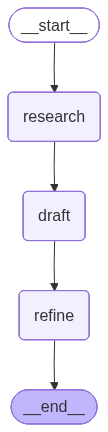

In [8]:
# Visualize the graph structure (requires graphviz)
try:
    from IPython.display import Image, display
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print Mermaid diagram code
    print(agent.get_graph().draw_mermaid())

In [9]:
product_input: AgentState = {
    "product_name": "AuraSound Pro X1 Wireless Headphones",
    "product_category": "Consumer Electronics / Audio",
    "key_features": [
        "Active Noise Cancellation (ANC) with 3 modes",
        "40-hour battery life with fast charge (10 min = 3 hrs)",
        "Bluetooth 5.3 with multipoint connection (2 devices)",
        "Premium 40mm custom drivers with Hi-Res Audio certification",
        "Ultra-comfortable memory foam ear cushions",
        "Foldable design with premium carry case",
        "Built-in voice assistant support (Alexa, Google, Siri)",
    ],
    "target_audience": "remote workers, frequent travelers, and audiophiles aged 25-45",
    "tone": "professional yet approachable",

    "research_notes": None,
    "draft_description": None,
    "final_description": None
}

print("✅ Product input ready. Running agent...\n")
print("=" * 60)

result = agent.invoke(product_input)

print("=" * 60)
print("\n🎉 Agent complete!")

✅ Product input ready. Running agent...

Research node runing....!
✅ Research complete
✍️  DRAFT node running...
 ✅ Draft complete
refine node running....
✅ Refinement complete

🎉 Agent complete!


In [10]:
from IPython.display import Markdown, display

# ── Research Notes ──
print("=" * 60)
print("🔍 RESEARCH NOTES")
print("=" * 60)
display(Markdown(result["research_notes"]))

🔍 RESEARCH NOTES


## 1) Top 3 Unique Selling Points (USPs)

1. **“All-day, everywhere” power + fast-charge safety net**
   - **40-hour battery** supports multiple workdays or long-haul travel without anxiety.
   - **10 minutes = 3 hours** gives an immediate rescue option before meetings/boarding.

2. **Adaptive focus control with ANC in 3 modes**
   - **Three noise-canceling modes** lets users match their environment (office chatter, airplane cabin, café noise) instead of a one-size-fits-all ANC.
   - Clear positioning: *switch from deep focus → aware mode → balanced commuting* as your day changes.

3. **Premium sound + modern connectivity built for real multitasking**
   - **40mm custom drivers + Hi‑Res Audio certification** signals “audiophile-grade” detail, not just louder bass.
   - **Bluetooth 5.3 + multipoint (2 devices)** makes it practical: seamless laptop/phone switching for calls, music, and meetings.

---

## 2) Customer Pain Points (problems this solves)

### Remote workers
- **Can’t focus at home/co-working spaces** due to voices, HVAC, street noise → *ANC modes create a controlled work bubble.*
- **Meeting fatigue & call disruptions** from constant device switching → *multipoint + voice assistants reduce friction.*
- **Headphone discomfort over long sessions** → *memory foam cushions for extended wear.*

### Frequent travelers
- **Airplane/train noise and announcement chaos** → *ANC modes help tune out engines while retaining situational awareness when needed.*
- **Battery dying mid-flight or mid-connection** → *40 hours + fast charge covers long itineraries.*
- **Bulky gear and damaged headphones in bags** → *foldable design + premium carry case makes it packable and protected.*

### Audiophiles (25–45)
- **Compressed, “flat” wireless sound** → *Hi‑Res certification + custom drivers emphasize clarity, separation, and detail.*
- **Latency/connection instability** (especially in crowded wireless environments) → *Bluetooth 5.3 improves efficiency and stability.*
- **Build/comfort not matching sound quality** → *premium comfort + travel-ready construction supports daily use.*

---

## 3) Emotional Benefits (how they feel after buying)

- **In control and focused:** able to “turn the world down” on demand and concentrate.
- **Confident and prepared:** battery and fast charge remove the worry of being stranded without audio for calls or travel.
- **Upgraded and proud of their gear:** premium sound + Hi‑Res positioning gives the feeling of owning a serious audio product.
- **Comfortably immersed:** cushioned fit supports long listening/working without the “get these off my head” frustration.
- **Effortless and efficient:** smooth switching between devices makes them feel organized and professional.

---

## 4) SEO Keywords (8–10 buyer search terms)

1. wireless noise cancelling headphones  
2. ANC headphones with multiple modes  
3. 40 hour battery Bluetooth headphones  
4. fast charging headphones 10 minutes  
5. Bluetooth 5.3 multipoint headphones  
6. headphones for remote work meetings  
7. travel headphones with carry case foldable  
8. Hi-Res Audio wireless headphones  
9. memory foam over ear headphones  
10. voice assistant headphones Alexa Google Siri  

---

## 5) Tone Recommendations (professional yet approachable)

- **Lead with outcomes, then specs:** “Stay focused in noisy spaces” → then mention “3-mode ANC.”
- **Use clear, confident language; avoid hype:** say “Hi‑Res certified” and “custom 40mm drivers” rather than “mind-blowing.”
- **Speak to real-life scenarios:** “Switch from laptop calls to phone music without reconnecting.”
- **Keep sentences punchy and scannable:** short paragraphs, benefit-led bullets, minimal jargon.
- **Use credibility cues:** mention certifications (Hi‑Res), version numbers (Bluetooth 5.3), and measurable claims (40 hours, 10 min = 3 hours).
- **Warm but not casual:** “built for long workdays and long flights” instead of slang.

---

## 6) Competitor Positioning (how to differentiate in the Consumer Electronics / Audio market)

**Primary competitive set:** mainstream ANC leaders (e.g., Sony/Bose/Sennheiser) + mid-tier Amazon brands competing on price.

### Differentiation angles to emphasize
- **“Work + travel + audiophile” trifecta**
  - Many competitors excel in *one* lane (travel ANC or audiophile sound). Position AuraSound Pro X1 as the **bridge**: *focus-grade ANC, hi-res sound, and practical multipoint.*

- **3-mode ANC as a daily workflow feature (not just a spec)**
  - Frame modes around use cases:  
    - *Deep Focus (home/office)*  
    - *Commute/Travel (engines & crowds)*  
    - *Aware/Transparency-style mode (announcements & quick conversations)*  
  - This helps stand out in a crowded “ANC” market where many listings sound identical.

- **Battery + fast charge as “reliability insurance”**
  - Competing products may offer long battery OR fast charge; lead with the combined promise: **40 hours + 10-minute top-up** for busy professionals.

- **Multipoint + voice assistants = fewer friction points**
  - Highlight “no re-pairing, no menu digging” convenience. This is especially persuasive for remote workers comparing options.

- **Comfort + portability as premium ownership experience**
  - Memory foam + foldable + premium case signals “daily driver” durability and comfort—important against cheaper lookalikes.

### Practical messaging strategy vs competitors
- **Avoid feature copying; anchor on moments:**
  - “From back-to-back Zoom calls to a red-eye flight—one headset, no compromises.”
- **Proof-friendly claims:**
  - Use measurable numbers (battery, fast charge time, Bluetooth 5.3) and official labels (Hi‑Res) to build trust quickly in product pages and ads.

In [11]:
# ── Draft Description ──
print("=" * 60)
print("✍️  DRAFT DESCRIPTION")
print("=" * 60)
display(Markdown(result["draft_description"]))

✍️  DRAFT DESCRIPTION


**HEADLINE**  
Focus Anywhere with AuraSound Pro X1

**OPENING HOOK**  
Turn noisy days into calm, productive hours—whether you’re in a busy home office, a crowded café, or 30,000 feet in the air. AuraSound Pro X1 gives you the control to tune in, tune out, and stay comfortably immersed from the first call to the last track.

**PRODUCT DESCRIPTION**  
The AuraSound Pro X1 are wireless noise cancelling headphones built for modern work, travel, and serious listening. With ANC headphones with multiple modes, you can switch between Deep Focus, Travel/Commute, and Aware-style listening depending on your environment. Premium 40mm custom drivers with Hi‑Res Audio certification deliver detail and separation that elevate streaming, playlists, and podcasts alike. Bluetooth 5.3 multipoint headphones connect to two devices at once, so your laptop meeting and phone music stay seamless.

**KEY FEATURES**  
- **Stay focused in noisy spaces** — Active Noise Cancellation (ANC) with 3 modes for office, commute, and awareness  
- **Go for days without charging** — 40 hour battery Bluetooth headphones performance for long workweeks and long-haul trips  
- **Never get caught at 1%** — Fast charging headphones 10 minutes = 3 hours of playback  
- **Switch devices without re-pairing** — Bluetooth 5.3 + multipoint connection for 2 devices  
- **Hear more detail, not just more volume** — 40mm custom drivers + Hi‑Res Audio wireless headphones certification  
- **Wear them for hours comfortably** — Memory foam over ear headphones cushions designed for all-day comfort  
- **Pack and protect with ease** — Foldable design + travel headphones with carry case included

**WHO IT'S FOR**  
Ideal for remote workers who need reliable headphones for remote work meetings, frequent travelers who want calm on the move, and audiophiles (25–45) who won’t settle for flat wireless sound.

**CALL TO ACTION**  
Upgrade your daily grind and your next trip—add AuraSound Pro X1 to your cart and press play.

In [12]:
# ── Final Polished Description ──
print("=" * 60)
print("✨ FINAL PRODUCT DESCRIPTION (Ready to Publish)")
print("=" * 60)
display(Markdown(result["final_description"]))

✨ FINAL PRODUCT DESCRIPTION (Ready to Publish)


**HEADLINE**  
Own Your Sound with AuraSound Pro X1

**OPENING HOOK**  
Take back your focus anywhere—home office, packed café, or mid‑flight. AuraSound Pro X1 lets you dial in the right level of quiet, stay clear on calls, and enjoy immersive audio from the first meeting to the last track.

**PRODUCT DESCRIPTION**  
AuraSound Pro X1 wireless noise cancelling headphones are built for modern work, travel, and serious listening. Choose the right sound profile fast with Active Noise Cancellation (ANC) modes for Deep Focus, Travel/Commute, or Aware-style listening when you need to stay alert. Custom 40mm drivers with Hi‑Res Audio certification deliver clean detail and separation—so playlists hit harder, podcasts sound clearer, and streaming feels more lifelike. Bluetooth 5.3 multipoint keeps two devices connected at once, making it easy to switch between laptop calls and phone audio without re‑pairing.

**KEY FEATURES**  
- **Block distractions and stay locked in** — ANC with 3 modes for focused work, commuting, and awareness  
- **Power through long weeks and long flights** — Up to 40 hours of battery life on a single charge  
- **Get hours of playback in minutes** — Fast charging: 10 minutes delivers up to 3 hours of listening  
- **Move from meetings to music instantly** — Bluetooth 5.3 multipoint connects to 2 devices at once  
- **Hear nuance, layers, and clarity** — 40mm custom drivers with Hi‑Res Audio certification  
- **Stay comfortable through back-to-back sessions** — Memory foam over‑ear cushions made for all‑day wear  
- **Travel lighter and pack faster** — Foldable design with a protective carry case included

**WHO IT'S FOR**  
Made for remote workers who need dependable headphones for remote work meetings, frequent travelers who want calm on the move, and audiophiles ages 25–45 who expect detail—not flat wireless sound.

**CALL TO ACTION**  
Upgrade your workday and your next trip—add AuraSound Pro X1 to your cart now and take control of your sound.

In [14]:
import asyncio

products = [
    {
        "product_name":     "EcoBreeze Bamboo Water Bottle",
        "product_category": "Sustainable Lifestyle",
        "key_features":     ["100% organic bamboo exterior", "500ml capacity", "Leak-proof lid", "Keeps drinks cold 24hrs"],
        "target_audience":  "eco-conscious millennials and hikers",
        "tone":             "earthy and inspiring",
        "research_notes": None, "draft_description": None, "final_description": None,
    },
    {
        "product_name":     "CloudStep Memory Foam Slippers",
        "product_category": "Footwear / Home",
        "key_features":     ["3-layer memory foam sole", "Machine washable", "Non-slip rubber bottom", "Available in 6 colors"],
        "target_audience":  "adults seeking premium home comfort",
        "tone":             "cozy and warm",
        "research_notes": None, "draft_description": None, "final_description": None,
    },
]

print(f"Running agent on {len(products)} products...\n")

batch_results = []

for i, product in enumerate(products, 1):
    print(f"Processing product {i}/{len(products)}: {product['product_name']}")
    result = agent.invoke(product)
    batch_results.append(result)
    print(f"    ✅ Done\n")

print("🎉 all priducts are procesed")

Running agent on 2 products...

Processing product 1/2: EcoBreeze Bamboo Water Bottle
Research node runing....!
✅ Research complete
✍️  DRAFT node running...
 ✅ Draft complete
refine node running....
✅ Refinement complete
    ✅ Done

Processing product 2/2: CloudStep Memory Foam Slippers
Research node runing....!
✅ Research complete
✍️  DRAFT node running...
 ✅ Draft complete
refine node running....
✅ Refinement complete
    ✅ Done

🎉 all priducts are procesed


In [15]:
# Display all final descriptions
for result in batch_results:
    print("\n" + "=" * 60)
    print(f"✨ {result['product_name']}")
    print("=" * 60)
    display(Markdown(result["final_description"]))


✨ EcoBreeze Bamboo Water Bottle


**HEADLINE**  
EcoBreeze Bamboo Water Bottle: Refill Anywhere, Wander Lighter

**OPENING HOOK**  
Bring the calm of the outdoors into your everyday. The EcoBreeze Bamboo Water Bottle pairs a warm, natural feel with trail-ready insulation—so your hydration stays mindful, low-waste, and effortlessly part of the routine.

**PRODUCT DESCRIPTION**  
EcoBreeze is a sustainable, reusable water bottle built for commutes, errands, and day hikes—finished in a 100% organic bamboo exterior for an earthy, minimalist look. The 500ml size slides into most cup holders and packs without the bulk, making it an easy grab on busy mornings and early trail starts. Inside, insulated performance keeps water cold for up to 24 hours, so every sip stays crisp from trailhead to desk. A leak-proof lid seals tight to protect your bag, your layers, and your peace of mind—refill culture, made simple.

**KEY FEATURES**  
- **Start your day feeling grounded** — 100% organic bamboo exterior with a natural, tactile finish  
- **Stay cool on the move** — insulated water bottle keeps drinks cold for up to 24 hours  
- **Toss it in your pack without worry** — leak-proof lid helps prevent spills on laptops and gear  
- **Cut single-use plastic, one refill at a time** — eco friendly water bottle made for everyday use  
- **Keep it light and easy to carry** — 500ml capacity fits grab-and-go routines and day hikes  
- **Match your trail-to-town style** — minimalist eco water bottle design that blends into any setup  

**WHO IT'S FOR**  
For eco-conscious millennials and hikers who want a plastic free water bottle with natural style, dependable performance, and an easy-to-pack size for everyday refills.

**CALL TO ACTION**  
Refill today—take EcoBreeze on your next hike, commute, or coffee run and make low-waste hydration your new default.


✨ CloudStep Memory Foam Slippers


**HEADLINE**  
Cloud-Like Comfort That Supports Every Step at Home

**OPENING HOOK**  
Slip in, exhale, and let the day ease off your feet. CloudStep Memory Foam Slippers turn chilly floors and tired soles into a cozy ritual—from first coffee to last call for the couch.

**PRODUCT DESCRIPTION**  
CloudStep is a premium house slipper built for real life at home—working, cooking, lounging, and everything in between. The 3-layer memory foam sole cushions impact and supports your stride, so hard floors feel softer on your heels and arches. A non-slip rubber outsole helps you move confidently on hardwood and tile without the careful shuffle. And when spills and everyday wear happen, just toss them in the wash for fresh, comfortable slippers again.

**KEY FEATURES**  
- **Softer steps on hard floors** — 3-layer memory foam cushions heels and supports your stride  
- **Lasting comfort, day after day** — layered design helps resist flattening compared to basic foam slippers  
- **Safer movement indoors** — non-slip rubber outsole grips on smooth floors like hardwood and tile  
- **Easy to keep fresh** — machine washable slippers for quick, clean resets  
- **Warmth without the heavy feel** — plush, snug comfort that stays easy to slip on  
- **A look that fits your space** — choose from 6 colors for your home vibe (or an easy gift)

**WHO IT'S FOR**  
Made for adults who want premium home comfort with supportive cushioning—especially if you spend hours on hardwood floors, prefer non-slip slippers for everyday peace of mind, or want machine-washable ease.

**CALL TO ACTION**  
Pick your color now and upgrade your at-home comfort—step into CloudStep today.

In [16]:
import json
import csv
from datetime import datetime


timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

json_path = f"Product description {timestamp}.json"

export_date = [
    {
        "product_name":      r["product_name"],
        "category":          r["product_category"],
        "tone":              r["tone"],
        "final_description": r["final_description"],
        "research_notes":    r["research_notes"],
    } for r in batch_results
]

with open(json_path, "w") as f:
    json.dump(export_date, f, indent=2)
print("exported to json_path: ", {json_path})


csv_path = f"product_description_{timestamp}.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["product_name", "category", "tone", "final_description"])
    writer.writeheader()
    for r in export_date:
        writer.writerow({k: v for k, v in r.items() if k != "research_notes"})
print(f"exported to {csv_path}")

exported to json_path:  {'Product description 20260321_231438.json'}
exported to product_description_20260321_231438.csv
